In [1]:
## -- System dependencies --
import sys, os, gc
import torch

## -- Device-Agnostic for GPU --
if torch.cuda.is_available():
    print(f"ℹ️ Device GPU: {torch.cuda.get_device_name(0)}")
    print(f"ℹ️ No. of CPU: {os.cpu_count()} cores")
    # get_ipython().run_line_magic('load_ext', 'cudf.pandas')
    # get_ipython().run_line_magic('load_ext', 'cuml.accel')
    # from cuml.preprocessing import TargetEncoder as cuTE
else:
    print(f"ℹ️ Device: CPU {os.cpu_count()} cores")

ℹ️ Device GPU: Tesla T4
ℹ️ No. of CPU: 4 cores


In [2]:
## -- Data Manipulation --
import numpy as np, pandas as pd, random

## -- Visualization --
from IPython.display import display, Image
import matplotlib.pyplot as plt
import seaborn as sns

## -- Functional Tools --
import itertools
from time import time, sleep
from tqdm.notebook import tqdm
from scipy.special import expit

import tensorflow as tf

## -- Machine Learning --
import sklearn
from sklearn.base import clone
from sklearn.frozen import FrozenEstimator
from sklearn.utils.class_weight import compute_class_weight
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV
from sklearn.model_selection import KFold, StratifiedKFold, train_test_split
from sklearn.metrics import roc_auc_score, log_loss, ConfusionMatrixDisplay, RocCurveDisplay

import warnings
warnings.simplefilter('ignore')
warnings.filterwarnings('ignore')

2026-05-27 14:24:27.222662: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779891867.627423      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779891867.747044      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779891868.764177      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779891868.764221      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779891868.764224      23 computation_placer.cc:177] computation placer alr

In [3]:
## -- Set Configuration --
class CFG:
    FOLDS = 5
    SEED = 42
    GREEN  = '\033[32m'
    YELLOW = '\033[33m'
    RED    = '\033[31m'
    RESET  = '\033[0m'

# sklearn.set_config(transform_output="pandas")
# pd.options.mode.copy_on_write = True

pd.set_option('display.max_columns', 1000)
sns.set_style("whitegrid")
# plt.style.use('ggplot')

# plt.rcParams['axes.prop_cycle'] = cycler(color=['red', 'green', 'blue'])
plt.rcParams.update({
    "figure.facecolor": '#0f0f1a', # Outer panel (figure)
    "axes.facecolor":   '#1a1a2e', # Inner panel (image)
    "axes.edgecolor":   '#444466',
    "axes.labelcolor":  '#e0e0ff',
    "text.color":       'lightblue',
    "xtick.color":      '#e0e0ff',
    "ytick.color":      '#e0e0ff',
    "grid.color":       '#2a2a4a',
    "grid.alpha":       0.5,
    "font.family":      'monospace',
})

PALETTE = ['c', 'r', 'darkorange', '#3A86FF', 'y']
sns.set_palette(PALETTE)
cmap = sns.diverging_palette(0, 230, 90, 60, as_cmap=True)

print(f"CLASSIC {CFG.GREEN} GREEN {CFG.RESET} {CFG.YELLOW} YELLOW {CFG.RESET} {CFG.RED} RED {CFG.RESET}")

CLASSIC  GREEN   YELLOW   RED 


In [4]:
## -- ⚠️ IMPORTANT: SELECT PLATFORM ⚠️ --
PLATFORM = 'kaggle' # -> 'colab' 'kaggle'

if PLATFORM == 'kaggle':
    PATH = '/kaggle/input/competitions/playground-series-s6e5/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+"train.csv").drop(columns=['id'])
    test = pd.read_csv(PATH+"test.csv").drop(columns=['id'])
    ORIG_PATH = '/kaggle/input/datasets/aadigupta1601/f1-strategy-dataset-pit-stop-prediction/'
    orig = pd.read_csv(ORIG_PATH+'f1_strategy_dataset_v4.csv')#.drop(['customerID'], axis=1)
elif PLATFORM == 'colab':
    from google.colab import drive
    drive.mount('/content/drive')

    PATH = '/content/drive/MyDrive/--colab--notebooks--/Ps6e5 | F1 Pits Stop/_f1_data/'
    submit = pd.read_csv(PATH+'sample_submission.csv')
    train = pd.read_csv(PATH+'train.csv').drop(columns=['id'])
    test = pd.read_csv(PATH+'test.csv').drop(columns=['id'])
    orig = pd.read_csv(PATH+'f1_strategy_dataset_v4.csv')#.drop(['customerID'], axis=1)

## =================================================================================

TARGET = train.columns[-1]

CATS = [c for c in test.columns if test[c].dtype in ['str', 'object', 'category']]
NUMS = [c for c in test.columns if c not in CATS+[TARGET]]
BASE = NUMS + CATS

orig = orig[train.columns]

for (name, df) in dict(Train=train, Test=test, Original=orig).items():
    print(f"{name} shape: {df.shape}")

print(f"\nTotal Nums: {len(NUMS)}")
print(f"Total Cats: {len(CATS)}")
print(f"Total Base: {len(BASE)}")

Train shape: (439140, 15)
Test shape: (188165, 14)
Original shape: (101371, 15)

Total Nums: 11
Total Cats: 3
Total Base: 14


In [5]:
exclude_ = [c for c in orig['Race'].unique() if c not in train['Race'].unique()]
print('Varibale differences in Race feature:', exclude_)

orig[orig['Race'].isin(exclude_)].groupby(['Race'])[TARGET].size()

Varibale differences in Race feature: ['Pre-Season Test', 'Pre-Season Track Session']


Race
Pre-Season Test             918
Pre-Season Track Session    773
Name: PitNextLap, dtype: int64

In [6]:
## -- Fix differences --
orig['Race'].replace(exclude_, 'Pre-Season Testing', inplace=True)
orig['Compound'].fillna('unknown', inplace=True)

In [7]:
display(train.head())
train.info()

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
0,D109,HARD,Canadian Grand Prix,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,1.0
1,D086,HARD,Dutch Grand Prix,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,0.0
2,ZON,HARD,Austrian Grand Prix,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,1.0
3,SPE,MEDIUM,Pre-Season Testing,2023,0,2,1,2.0,7,94.361,-7.324,-7.324,0.076923,0.0,0.0
4,D019,HARD,Azerbaijan Grand Prix,2022,1,26,3,6.0,2,107.878,8.965,-14.139,0.361111,3.0,0.0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 439140 entries, 0 to 439139
Data columns (total 15 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   Driver                  439140 non-null  object 
 1   Compound                439140 non-null  object 
 2   Race                    439140 non-null  object 
 3   Year                    439140 non-null  int64  
 4   PitStop                 439140 non-null  int64  
 5   LapNumber               439140 non-null  int64  
 6   Stint                   439140 non-null  int64  
 7   TyreLife                439140 non-null  float64
 8   Position                439140 non-null  int64  
 9   LapTime (s)             439140 non-null  float64
 10  LapTime_Delta           439140 non-null  float64
 11  Cumulative_Degradation  439140 non-null  float64
 12  RaceProgress            439140 non-null  float64
 13  Position_Change         439140 non-null  float64
 14  PitNextLap          

In [8]:
train.describe()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap
count,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000,439140.000000
mean,2023.523544,0.136118,23.105909,1.789113,14.158231,9.630339,90.948735,-3.770040,-25.721759,0.337661,0.101542,0.198982
std,1.024930,0.342915,16.958261,0.950194,9.801338,5.278770,19.772769,43.945759,54.766573,0.253277,4.006765,0.399235
min,2022.000000,0.000000,1.000000,1.000000,1.000000,1.000000,67.694000,-2403.895000,-274.564000,0.012821,-18.000000,0.000000
25%,2023.000000,0.000000,9.000000,1.000000,6.000000,5.000000,82.621000,-8.884000,-46.566250,0.129870,-1.000000,0.000000
50%,2024.000000,0.000000,19.000000,2.000000,12.000000,10.000000,90.521000,-0.295000,-20.994000,0.269231,0.000000,0.000000
75%,2024.000000,0.000000,36.000000,2.000000,20.000000,14.000000,98.471000,0.115000,-6.199000,0.513158,2.000000,0.000000
max,2025.000000,1.000000,78.000000,8.000000,77.000000,20.000000,2507.607000,2423.932000,2412.026000,1.000000,18.000000,1.000000


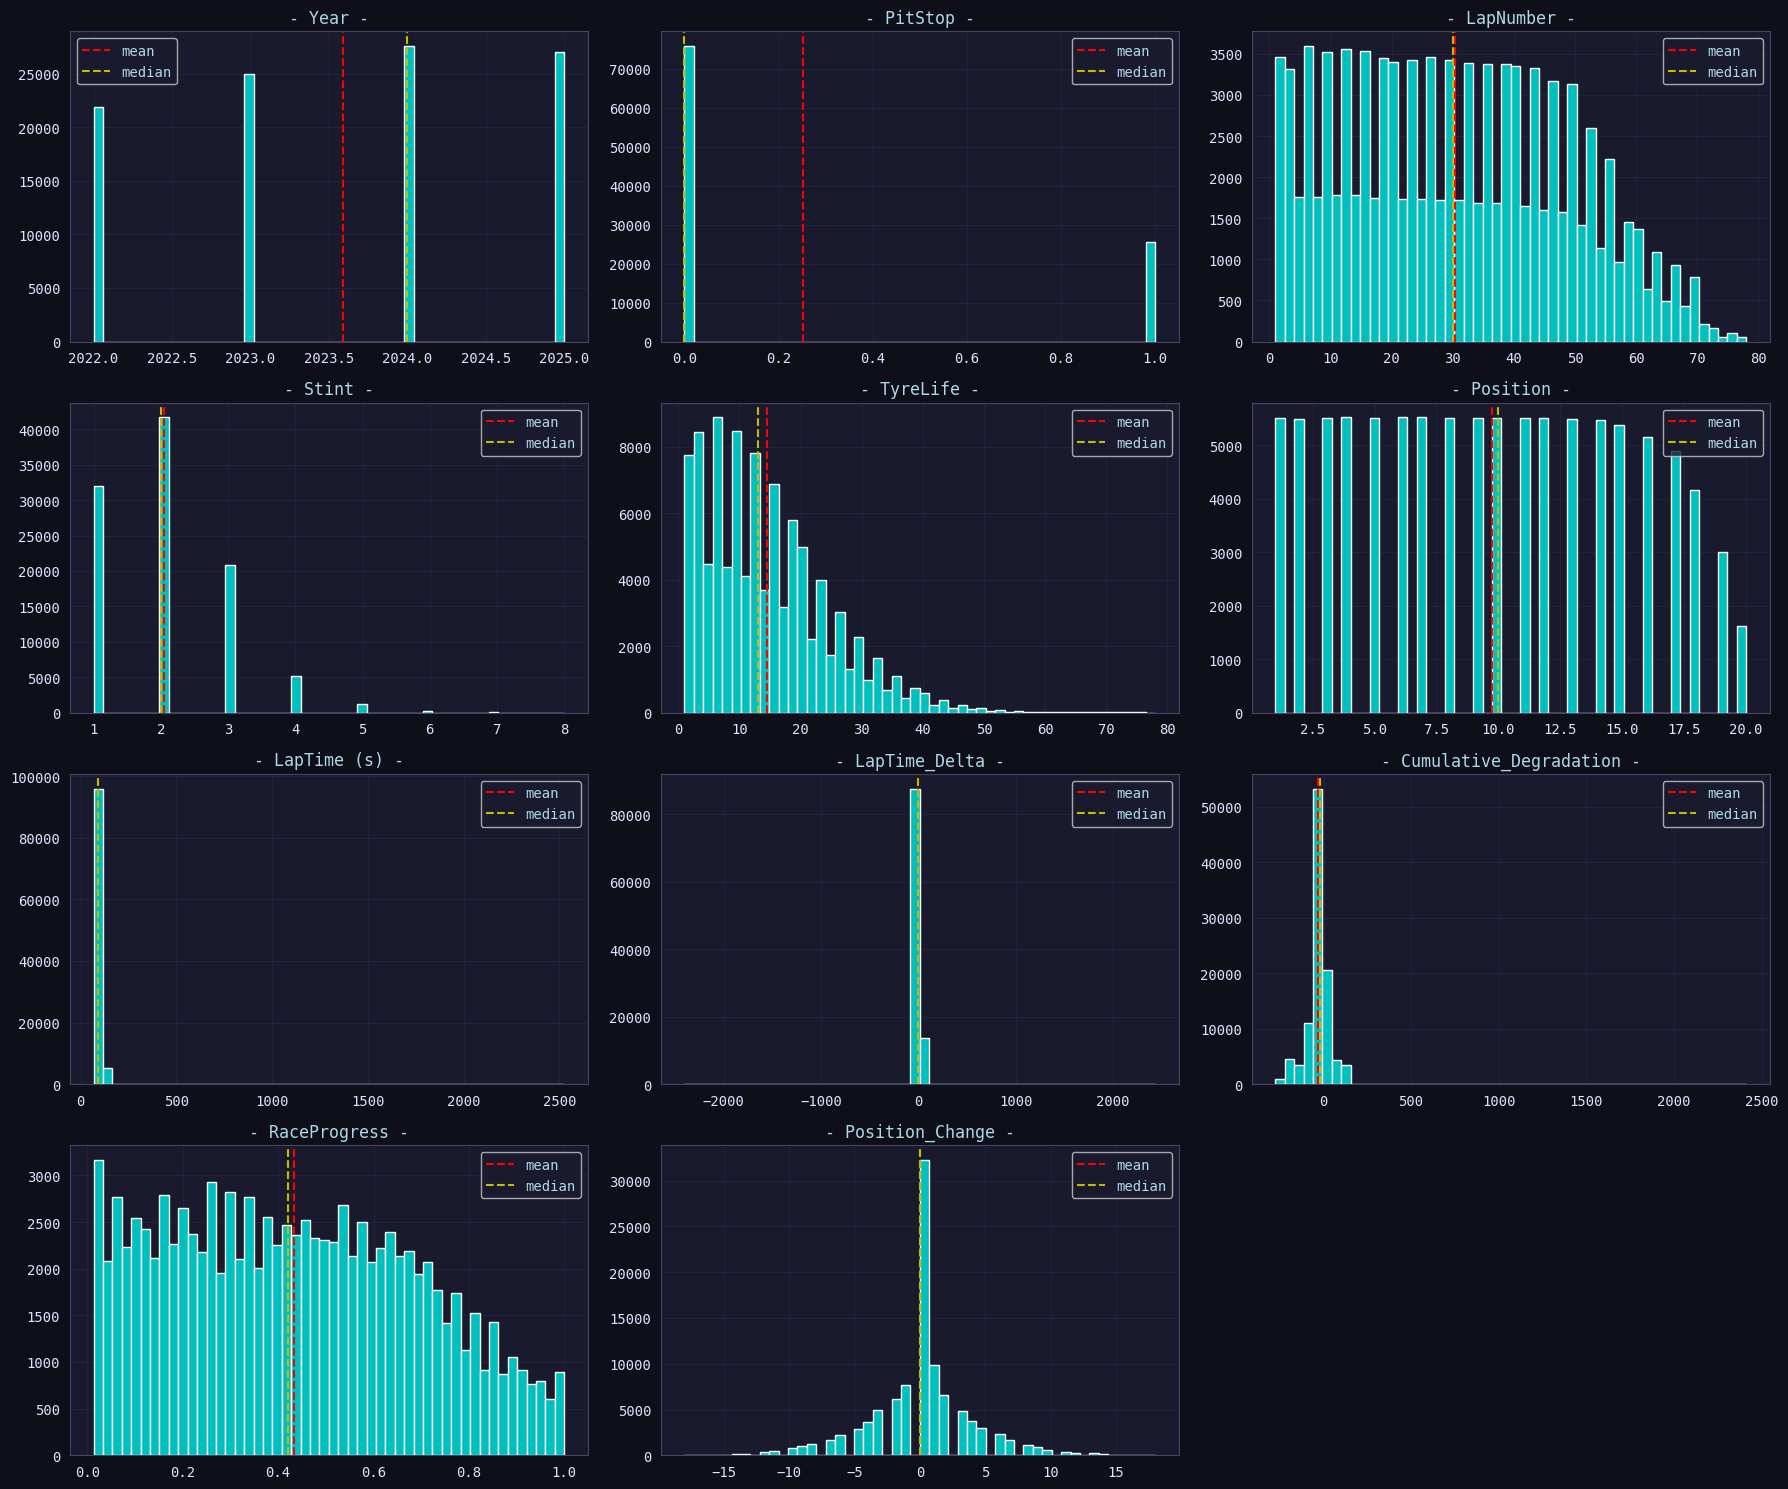

In [9]:
plt.figure(figsize=(18, 15))

for i, col in enumerate(NUMS):
    plt.subplot(4, 3, i+1)
    ax = plt.hist(orig[col], bins=50)
    plt.axvline(x=orig[col].mean(), color='r', linestyle='--', label='mean')
    plt.axvline(x=orig[col].median(), color='y', linestyle='--', label='median')
    plt.title(f'- {col} -')
    plt.legend()

plt.tight_layout()
plt.show()

In [10]:
## -- Unique value counts for each dataset --
TRAIN_UNIQUE = {}
ORIGINAL_UNIQUE = {}
TEST_UNIQUE = {}

for col in BASE:
    TRAIN_UNIQUE[col] = train[col].nunique()
    ORIGINAL_UNIQUE[col] = orig[col].nunique()
    TEST_UNIQUE[col] = test[col].nunique()

unique_counts_df = pd.concat(
        [pd.DataFrame(TRAIN_UNIQUE, index=['Train']),
         pd.DataFrame(ORIGINAL_UNIQUE, index=['Original']),
         pd.DataFrame(TEST_UNIQUE, index=['Test'])],
    )

unique_counts_df.style.background_gradient()

,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,Driver,Compound,Race
Train,4,2,78,8,78,20,37719,57532,142701,1898,37,887,5,26
Original,4,2,78,8,78,20,40779,54084,81360,1437,37,31,6,26
Test,4,2,77,8,77,20,30286,40673,86823,1556,37,801,5,26


In [11]:
n_unique = train[BASE].nunique().sort_values()
n_unique

PitStop                        2
Year                           4
Compound                       5
Stint                          8
Position                      20
Race                          26
Position_Change               37
LapNumber                     78
TyreLife                      78
Driver                       887
RaceProgress                1898
LapTime (s)                37719
LapTime_Delta              57532
Cumulative_Degradation    142701
dtype: int64

In [12]:
# ## -- Optimal Binning --
# try:
#     import optbinning
# except:
#     %pip install -q -U optbinning
#     import optbinning

# def _opt_binning(
#     x_tr, y_tr, x_vl, x_ts, bin_features, method='cart',
#     solver='cp', metric='woe', pre_bins=20, period=100):
#     """
#     metric: 'mean_woe' or 'weighted_mean_woe': floats or 'indices': integers
#     """
#     x_train = x_tr.copy()
#     x_valid = x_vl.copy()
#     x_test  = x_ts.copy()

#     for c in bin_features:
#         if x_train[c].dtype in ['str', 'object', 'category']:
#             combine  = pd.concat([x_train[c], x_valid[c], x_test[c]])
#             combine  = combine.factorize()[0]
#             # combine  = pd.Series(combine).astype('category')
#             x_train[c] = combine[:len(x_train)]
#             x_valid[c] = combine[len(x_train):len(x_train)+len(x_valid)]
#             x_test[c]  = combine[-len(x_test):]

#     opt_modules_per_col = []
#     opt_cols = []

#     # print(f'OptimalBinning {len(bin_features)}: ', end='')
#     for col in tqdm(bin_features, desc='Optimal_Binning'):
#         # print(f'{col}... ', end='')
#         opt_b = optbinning.OptimalBinning(
#             name=col,
#             dtype='numerical',
#             prebinning_method=method, # d='cart', 'quantile'
#             # class_weight='balanced',
#             # min_prebin_size=0.02, # d=0.05
#             # cat_cutoff=0.01,
#             solver=solver,
#             max_n_prebins=pre_bins, # d=20
#             # min_n_bins=2, max_n_bins=100,
#             # min_bin_size=0.1, max_bin_size=0.9,
#             time_limit=period, # d=100 (secs)
#             # verbose=True,
#         )

#         opt_b.fit(x_train[col].to_numpy(), y_tr.to_numpy())

#         new_col = f'{col}_optBin'
#         x_train[new_col] = opt_b.transform(x_train[col].to_numpy(), metric=metric)
#         x_valid[new_col] = opt_b.transform(x_valid[col].to_numpy(), metric=metric)
#         x_test[new_col]  = opt_b.transform(x_test[col].to_numpy(),  metric=metric)

#         opt_cols.append(new_col)
#         opt_modules_per_col.append(opt_b)

#     return opt_modules_per_col, opt_cols, x_train, x_valid, x_test

# print('Binning function ready')

In [13]:
# opt_bins, opt_bin_cols, train2, orig2, test2 = _opt_binning(
#     x_tr=train,
#     y_tr=train[TARGET],
#     x_vl=orig,
#     x_ts=test,
#     bin_features=n_unique.index[-5:],
#     method='cart', # 'cart', 'quantile'
#     solver='cp', # 'cp', 'mip', 'ls'
#     metric='woe', # 'woe','event_rate','indices','bins'
#     # pre_bins=100,
#     # period=100,
# )

# print(f"Total bin features: {len(opt_bin_cols)}")
# train2.head()

In [14]:
# BIN_TABLES = []

# for opt_ in opt_bins:
#     opt_table = opt_.binning_table
#     opt_table.build()
#     BIN_TABLES.append(opt_table)

# print('Optimal Binned Features:', len(BIN_TABLES))

# ## -- Plot optimal bin points --
# for i, opt_ in enumerate(BIN_TABLES):
#     opt_.plot(metric='event_rate', show_bin_labels=True, figsize=(18, 5))
#     print()

In [15]:
def get_weights(y, y_true, opt='auto'):
    """
    y: Current y labels -> numpy array or series
    y_true: True labels -> numpy array or series
    opt: 'auto' generate weight or pass a custom dict -> label: weight
    """
    if opt != 'auto':
        sample_weights = np.array([opt[label] for label in y])
        return sample_weights
    else:
        classes_ = np.unique(y_true)
        weights_ = compute_class_weight('balanced', classes=classes_, y=y_true)
        class_weights = dict(zip(classes_, weights_))
        sample_weights = np.array([class_weights[label] for label in y])
        return sample_weights

print('- Helper Functions Ready -')

- Helper Functions Ready -


## FEATURE ENGINEERING

In [16]:
train[NUMS].skew()

Year                      -0.000611
PitStop                    2.122297
LapNumber                  0.645965
Stint                      1.185479
TyreLife                   1.032448
Position                   0.070098
LapTime (s)               80.334328
LapTime_Delta            -40.855061
Cumulative_Degradation     3.191501
RaceProgress               0.699950
Position_Change           -0.092714
dtype: float64

In [17]:
## -- EXTRACTIONS & BINNING --
ROUNDS = []
DIGITS = []
E_BINS = []
Q_BINS = []
DROP_COLS = []

round_thresh = 3
digit_thresh = 2

round_thresh, digit_thresh

(3, 2)

In [18]:
_extract_cols = ['Cumulative_Degradation', 'LapTime (s)'] # , 'LapTime_Delta'

print(f"\nRounding... ", end='')
for col in _extract_cols:
    for r in range(-2, 3):
        r_n = f"{col}_round_{r}"
        print(r_n+', ', end='')
        train[r_n] = train[col].round(r).astype('int32')
        test[r_n]  = test[col].round(r).astype('int32')
        orig[r_n]  = orig[col].round(r).astype('int32')

        ## -- Drop irrelevant features --
        if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
            DROP_COLS.append(r_n)
        else:
            ROUNDS.append(r_n)

    # print(f"\nDIGITS... ", end='')
    # for d in [-3, -2, -1, 0, 1, 2, 3]:
    #     d_n = f'{col}_digit_{d}'
    #     print(d_n+', ', end='')
    #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
    #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
    #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')

    #     ## -- Drop constant features --
    #     if train[d_n].nunique() < digit_thresh:
    #         DROP_COLS.append(d_n)
    #     else:
    #         DIGITS.append(d_n)

    # print(f"\nCreating value-based E_BINS... ", end='')
    # for b in [100]:
    #     b_n = f'{col}_bin_{b}'
    #     print(b_n+', ', end='')
    #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
    #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     E_BINS.append(b_n)

    # print(f"\nCreating quantile-based Q_BINS... ", end='')
    # for q in [100]:
    #     q_n = f'{col}_Qbin_{q}'
    #     print(q_n+', ', end='')
    #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
    #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
    #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
    #     Q_BINS.append(q_n)

print()
print('='*50)
print(f'✅ Total ROUNDS: {len(ROUNDS)}')
print(f"✅ Total DIGITS: {len(DIGITS)}")
print(f"✅ Total E_BINS: {len(E_BINS)}")
print(f"✅ Total Q_BINS: {len(Q_BINS)}")


Rounding... Cumulative_Degradation_round_-2, Cumulative_Degradation_round_-1, Cumulative_Degradation_round_0, Cumulative_Degradation_round_1, Cumulative_Degradation_round_2, LapTime (s)_round_-2, LapTime (s)_round_-1, LapTime (s)_round_0, LapTime (s)_round_1, LapTime (s)_round_2, 
✅ Total ROUNDS: 10
✅ Total DIGITS: 0
✅ Total E_BINS: 0
✅ Total Q_BINS: 0


In [19]:
# print(f"\nRounding... ", end='')
# for col in ['LapTime (s)']:
#     for r in [-2, -1, 0, 1, 2]:
#         r_n = f"{col}_round_{r}"
#         print(r_n+', ', end='')
#         train[r_n] = train[col].round(r).astype('int32')
#         test[r_n]  = test[col].round(r).astype('int32')
#         orig[r_n]  = orig[col].round(r).astype('int32')
#         ## -- Drop irrelevant features --
#         if train[r_n].nunique() < round_thresh or train[r_n].nunique() == train[col].nunique():
#             DROP_COLS.append(r_n)
#         else:
#             ROUNDS.append(r_n)

#     # print(f"\nDIGITS... ", end='')
#     # for d in [0, 1, 2, 3, 4, 5, 6]:
#     #     d_n = f'{col}_digit_{d}'
#     #     print(d_n+', ', end='')
#     #     train[d_n] = ((train[col] * 10**d) % 10).fillna(-1).astype('int8')
#     #     test[d_n]  = ((test[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     orig[d_n]  = ((orig[col]  * 10**d) % 10).fillna(-1).astype('int8')
#     #     ## -- Drop constant features --
#     #     if train[d_n].nunique() < digit_thresh:
#     #         DROP_COLS.append(d_n)
#     #     else:
#     #         DIGITS.append(d_n)

#     # print(f"\nCreating value-based E_BINS... ", end='')
#     # for b in [10]:
#     #     b_n = f'{col}_bin_{b}'
#     #     print(b_n+', ', end='')
#     #     train[b_n], edges = pd.cut(train[col], bins=b, retbins=True, include_lowest=True, labels=False)
#     #     test[b_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[b_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     E_BINS.append(b_n)

#     # print(f"\nCreating quantile-based Q_BINS... ", end='')
#     # for q in [5]:
#     #     q_n = f'{col}_Qbin_{q}'
#     #     print(q_n+', ', end='')
#     #     train[q_n], edges = pd.qcut(train[col], q=q, retbins=True, duplicates='drop', labels=False)
#     #     test[q_n] = pd.cut(test[col], bins=edges, include_lowest=True, labels=False)
#     #     orig[q_n] = pd.cut(orig[col], bins=edges, include_lowest=True, labels=False)
#     #     Q_BINS.append(q_n)

# print()
# print('='*50)
# print(f'✅ Total ROUNDS: {len(ROUNDS)}')
# print(f"✅ Total DIGITS: {len(DIGITS)}")
# print(f"✅ Total E_BINS: {len(E_BINS)}")
# print(f"✅ Total Q_BINS: {len(Q_BINS)}")

In [20]:
train = train.drop(columns=DROP_COLS)
test  = test.drop(columns=DROP_COLS)
orig  = orig.drop(columns=DROP_COLS)

print(f"Features dropped: {DROP_COLS}")

Features dropped: []


In [21]:
train[ROUNDS+DIGITS+E_BINS+Q_BINS].nunique()

Cumulative_Degradation_round_-2      7
Cumulative_Degradation_round_-1     51
Cumulative_Degradation_round_0     454
Cumulative_Degradation_round_1     447
Cumulative_Degradation_round_2     445
LapTime (s)_round_-2                 5
LapTime (s)_round_-1                25
LapTime (s)_round_0                137
LapTime (s)_round_1                134
LapTime (s)_round_2                132
dtype: int64

In [22]:
# def add_frequency_condition(df1, cols, thresh=5):
#     df = df1.copy()
#     for c in cols:
#         v_counts = df[c].value_counts()
#         to_replace = v_counts[v_counts <= thresh].index
#         df[c] = np.where(df[c].isin(to_replace), -1, df[c])

#     return df

# train = add_frequency_condition(train, DIGITS+ROUNDS, thresh=5)
# test  = add_frequency_condition(test,  DIGITS+ROUNDS, thresh=5)
# orig  = add_frequency_condition(orig,  DIGITS+ROUNDS, thresh=5)

# print(f"Frequency threshold imputed!")

In [23]:
INTER = []
top_cols = ['PitStop', 'Year', 'Compound', 'Stint', 'Race']
low_cols = ['Driver', 'Position', 'Position_Change', 'LapNumber',]

for c1, c2 in tqdm(list(itertools.combinations(top_cols, 2)), desc='Pairwise'):
    n_col = f"Bi_{c1}-|-{c2}"
    train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
    test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
    orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
    INTER.append(n_col)

# for c1, c2, c3 in tqdm(list(itertools.combinations(top_cols, 3)), desc='Triplewise'):
#     n_col = f"Tri_{c1}-|-{c2}-|-{c3}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str) + '_' + train[c3].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str) + '_' + test[c3].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str) + '_' + test[c3].astype(str)
#     INTER.append(n_col)

# for c1, c2 in tqdm(list(itertools.product(top_cols, low_cols)), desc='One-to-Many'):
#     n_col = f"Bi_{c1}-|-{c2}"
#     train[n_col] = train[c1].astype(str) + '_' + train[c2].astype(str)
#     test[n_col]  = test[c1].astype(str) + '_' + test[c2].astype(str)
#     orig[n_col]  = orig[c1].astype(str) + '_' + orig[c2].astype(str)
#     INTER.append(n_col)

print(f"Total Interaction Features: {len(INTER)}")

Pairwise:   0%|          | 0/10 [00:00<?, ?it/s]

Total Interaction Features: 10


In [24]:
## -- Arithmetic interactions --
for df in [train, test, orig]:
    df['_LapNumber_div_RaceProgress'] = (df['LapNumber'] / (df['RaceProgress'] + 1e-6)).astype('float32')
    df['_TyreLife_div_LapNumber'] = (df['TyreLife'] / df['LapNumber'].clip(lower=1)).astype('float32')
    df['_LapTime_*_Cum_Degrad'] = (df['LapTime (s)'] * df['Cumulative_Degradation']).astype('float32')
    df['_LapTime_*_Cum_Degrad_abs'] = (df['LapTime (s)'] * df['Cumulative_Degradation'].abs()).astype('float32')
    df['_LapTime_div_Cum_Degrad_abs'] = (df['LapTime (s)'] / (df['Cumulative_Degradation'].abs() + 1e-6)).astype('float32')

arithmetic = [
    '_LapNumber_div_RaceProgress',
    '_TyreLife_div_LapNumber',
    '_LapTime_*_Cum_Degrad',
    '_LapTime_*_Cum_Degrad_abs',
    '_LapTime_div_Cum_Degrad_abs',
]

print(f"Total Arithmetic interactions: {len(arithmetic)}")

train[arithmetic].head()

Total Arithmetic interactions: 5


,_LapNumber_div_RaceProgress,_TyreLife_div_LapNumber,_LapTime_*_Cum_Degrad,_LapTime_*_Cum_Degrad_abs,_LapTime_div_Cum_Degrad_abs
0,69.999901,0.780000,1649.802368,1649.802368,3.734288
1,77.999771,0.259259,-16761.730469,16761.730469,0.336437
2,71.999908,0.372881,-7132.029785,7132.029785,0.705717
3,25.999662,1.000000,-691.099976,691.099976,12.883805
4,71.999802,0.230769,-1525.286987,1525.286987,7.629817


In [25]:
## -- Frequency encoding --
freq_cols = []

print(f"\nCreating frequencies... ", end='')
for col in CATS:
    freq = pd.concat([train[col], orig[col], test[col]]).value_counts(normalize=True)
    n = f'{col}_freq'
    print(n+', ', end='')
    for df in [train, test, orig]:
        df[n] = df[col].map(freq).fillna(0).astype('float32')
    freq_cols.append(n)

print(f"\n✓ Total frequency features: {len(freq_cols)}")


Creating frequencies... Driver_freq, Compound_freq, Race_freq, 
✓ Total frequency features: 3


In [26]:
from sklearn.base import BaseEstimator, TransformerMixin ## ===== Target/Category Mean ENCODERS =====

class TargetEncoder(BaseEstimator, TransformerMixin):
    """
    Target Encoder that supports multiple aggregation functions,
    internal cross-validation for leakage prevention, and smoothing.

    Parameters
    ----------
    cols_to_encode : list of str
        List of column names to be target encoded.

    aggs : list of str, default=['mean']
        List of aggregation functions to apply. Any function accepted by
        pandas' `.agg()` method is supported, such as:
        'mean', 'std', 'var', 'min', 'max', 'skew', 'nunique',
        'count', 'sum', 'median'.
        Smoothing is applied only to the 'mean' aggregation.

    cv : int, default=5
        Number of folds for cross-validation in fit_transform.

    smooth : float or 'auto', default='auto'
        The smoothing parameter `m`. A larger value puts more weight on the
        global mean. If 'auto', an empirical Bayes estimate is used.

    drop_original : bool, default=False
        If True, the original columns to be encoded are dropped.
    """
    def __init__(self, cols_to_encode, aggs=['mean'], cv=5, smooth='auto', drop_original=False):
        self.cols_to_encode = cols_to_encode
        self.aggs = aggs
        self.cv = cv
        self.smooth = smooth
        self.drop_original = drop_original
        self.mappings_ = {}
        self.global_stats_ = {}

    def fit(self, X, y):
        """
        Learn mappings from the entire dataset.
        These mappings are used for the transform method on validation/test data.
        """
        temp_df = X.copy()
        temp_df['target'] = y

        # Learn global statistics for each aggregation
        for agg_func in self.aggs:
            self.global_stats_[agg_func] = y.agg(agg_func)

        # Learn category-specific mappings
        for col in self.cols_to_encode:
            self.mappings_[col] = {}
            for agg_func in self.aggs:
                mapping = temp_df.groupby(col)['target'].agg(agg_func)
                self.mappings_[col][agg_func] = mapping

        return self

    def transform(self, X):
        """
        Apply learned mappings to the data.
        Unseen categories are filled with global statistics.
        """
        X_transformed = X.copy()
        for col in self.cols_to_encode:
            for agg_func in self.aggs:
                new_col_name = f'TE_{col}_{agg_func}'
                map_series = self.mappings_[col][agg_func]
                X_transformed[new_col_name] = X[col].map(map_series)
                X_transformed[new_col_name].fillna(self.global_stats_[agg_func], inplace=True)

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed

    def fit_transform(self, X, y):
        """
        Fit and transform the data using internal cross-validation to prevent leakage.
        """
        # First, fit on the entire dataset to get global mappings for transform method
        self.fit(X, y)

        # Initialize an empty DataFrame to store encoded features
        encoded_features = pd.DataFrame(index=X.index)

        kf = KFold(n_splits=self.cv, shuffle=True, random_state=42)

        for train_idx, val_idx in kf.split(X, y):
            X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
            X_val = X.iloc[val_idx]

            temp_df_train = X_train.copy()
            temp_df_train['target'] = y_train

            for col in self.cols_to_encode:
                # --- Calculate mappings only on the training part of the fold ---
                for agg_func in self.aggs:
                    new_col_name = f'TE_{col}_{agg_func}'

                    # Calculate global stat for this fold
                    fold_global_stat = y_train.agg(agg_func)

                    # Calculate category stats for this fold
                    mapping = temp_df_train.groupby(col)['target'].agg(agg_func)

                    # --- Apply smoothing only for 'mean' aggregation ---
                    if agg_func == 'mean':
                        counts = temp_df_train.groupby(col)['target'].count()

                        m = self.smooth
                        if self.smooth == 'auto':
                            # Empirical Bayes smoothing
                            variance_between = mapping.var()
                            avg_variance_within = temp_df_train.groupby(col)['target'].var().mean()
                            if variance_between > 0:
                                m = avg_variance_within / variance_between
                            else:
                                m = 0  # No smoothing if no variance between groups

                        # Apply smoothing formula
                        smoothed_mapping = (counts * mapping + m * fold_global_stat) / (counts + m)
                        encoded_values = X_val[col].map(smoothed_mapping)
                    else:
                        encoded_values = X_val[col].map(mapping)

                    # Store encoded values for the validation fold
                    encoded_features.loc[X_val.index, new_col_name] = encoded_values.fillna(fold_global_stat)

        # Merge with original DataFrame
        X_transformed = X.copy()
        for col in encoded_features.columns:
            X_transformed[col] = encoded_features[col]

        if self.drop_original:
            X_transformed.drop(columns=self.cols_to_encode, inplace=True)

        return X_transformed


class CategoryMeanTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, cat_cols=None):
        self.cat_cols = cat_cols
        self.mappings_ = {}
    def fit(self, X, y):
        X = X.copy()
        if self.cat_cols is None:
            self.cat_cols = X.select_dtypes(include=['category']).columns.tolist()
        self.mappings_ = {}
        for col in self.cat_cols:
            df_temp = pd.DataFrame({col: X[col], 'y': y})
            group_means = df_temp.groupby(col, dropna=False)['y'].mean()
            sorted_categories = group_means.sort_values().index
            self.mappings_[col] = {cat: i for i, cat in enumerate(sorted_categories)}
        return self

    def transform(self, X, y=None):
        X = X.copy()
        for col, mapping in self.mappings_.items():
            if col in X.columns:
                X[col] = X[col].map(mapping)
        return X

In [27]:
def orig_TE_data_propagate(
    orig: pd.DataFrame,
    X_train: pd.DataFrame,
    X_val: pd.DataFrame,
    X_test: pd.DataFrame,
    features: list=None,
    target: str=None,
    aggs: list=None,
    fill_nan: bool=False,
    ):

    if features is None or len(features) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    if aggs is None or len(aggs) == 0:
        return X_train.copy(), X_val.copy(), X_test.copy(), []

    X_train_df = X_train.copy()
    X_val_df   = X_val.copy()
    X_test_df  = X_test.copy()
    ORIG = []

    maps = {}

    valid_features = [col for col in features if col in orig.columns]

    for col in tqdm(valid_features, desc='TE_merging'):
        for agg_ in aggs:
            agg_key = agg_.lower()
            new_col = f"OTE_{col}_{agg_key}"

            map_key = (col, agg_key)
            if map_key not in maps:
                try:
                    if agg_key == 'mean':
                        map_df = (orig.groupby(col)[target].mean().reset_index(name=new_col))
                    elif agg_key == 'median':
                        map_df = (orig.groupby(col)[target].median().reset_index(name=new_col))
                    elif agg_key == 'count':
                        map_df = (orig.groupby(col).size().reset_index(name=new_col))
                    elif agg_key == 'nunique':
                        map_df = (orig.groupby(col)[target].nunique().reset_index(name=new_col))
                    elif agg_key == 'std':
                        map_df = (orig.groupby(col)[target].std().reset_index(name=new_col))
                    elif agg_key == 'skew':
                        map_df = (orig.groupby(col)[target].skew().reset_index(name=new_col))
                    elif agg_key == 'max':
                        map_df = (orig.groupby(col)[target].max().reset_index(name=new_col))
                    elif agg_key == 'min':
                        map_df = (orig.groupby(col)[target].min().reset_index(name=new_col))
                    else:
                        continue
                except Exception as e:
                    print(f"Warning: failed to create map for col={col}, agg={agg_}: {e}")
                    continue

                maps[map_key] = map_df

            map_df = maps.get(map_key)
            if map_df is None:
                continue

            # Merge maps into each split
            X_train_df = X_train_df.merge(map_df, on=col, how='left')
            X_val_df   = X_val_df.merge(map_df, on=col, how='left')
            X_test_df  = X_test_df.merge(map_df, on=col, how='left')

            ORIG.append(new_col)

    global_mean   = orig[target].mean()
    global_median = orig[target].median()

    def fill_conditionally(df):
        for c in ORIG:
            if '_mean' in c or '_max' in c or '_min' in c:
                df[c] = df[c].fillna(global_mean)
            elif '_median' in c:
                df[c] = df[c].fillna(global_median)
            else:
                df[c] = df[c].fillna(0)
        return df

    if fill_nan:
        X_train_df = fill_conditionally(X_train_df)
        X_val_df   = fill_conditionally(X_val_df)
        X_test_df  = fill_conditionally(X_test_df)

    return X_train_df, X_val_df, X_test_df, ORIG

In [28]:
# train, test, _, ORIG_COLS = orig_TE_data_propagate(
#     orig,
#     train,
#     test,
#     train.iloc[:500],
#     features=BASE, #+NUMS_FREQ, #
#     target=TARGET,
#     aggs=['mean', 'std'], # mean, median, count, std, skew, nunique, max, min
#     fill_nan=True,
# )

# print(f"Total original features: {len(ORIG_COLS)}")

In [29]:
# ## -- Duplicate all numerics as categories --
# CATS_2 = []
# nums_cats = [c for c in n_unique[n_unique < 1000].index if c not in CATS] #+ orig_cols

# for c in nums_cats:
#     n = f"cat_{c}"
#     train[n] = train[c].copy()
#     test[n]  = test[c].copy()
#     CATS_2.append(n)

#     ## -- Factorize --
#     combine  = pd.concat([train[n], test[n]])
#     __ = combine.factorize()[0]
#     train[n] = __[:len(train)].astype('int32')
#     test[n]  = __[len(train):].astype('int32')

# print(f'Numericals to Categoricals: {len(CATS_2)}')
# CATS_2

In [30]:
## -- Factorize using combined data --
for c in CATS:
    combine  = pd.concat([train[c], test[c], orig[c]])
    combine  = combine.factorize()[0]
    # combine  = pd.Series(combine).astype('category')
    train[c] = combine[:len(train)]
    test[c]  = combine[len(train):len(train)+len(test)]
    orig[c]  = combine[-len(orig):]

print('Label encoding complete!')

Label encoding complete!


In [31]:
## -- Flag 'Year' == 2023 --
for df in [train, test, orig]:
    df['is_2023'] = (df['Year'] == 2023).astype(int)

print('Flag Year:', 'is_2023')

Flag Year: is_2023


In [32]:
FEATURES = [c for c in train.columns if c not in ['id', TARGET]]
print('Total Features:', len(FEATURES))

train[FEATURES].head(3)

Total Features: 43


,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,Cumulative_Degradation_round_-2,Cumulative_Degradation_round_-1,Cumulative_Degradation_round_0,Cumulative_Degradation_round_1,Cumulative_Degradation_round_2,LapTime (s)_round_-2,LapTime (s)_round_-1,LapTime (s)_round_0,LapTime (s)_round_1,LapTime (s)_round_2,Bi_PitStop-|-Year,Bi_PitStop-|-Compound,Bi_PitStop-|-Stint,Bi_PitStop-|-Race,Bi_Year-|-Compound,Bi_Year-|-Stint,Bi_Year-|-Race,Bi_Compound-|-Stint,Bi_Compound-|-Race,Bi_Stint-|-Race,_LapNumber_div_RaceProgress,_TyreLife_div_LapNumber,_LapTime_*_Cum_Degrad,_LapTime_*_Cum_Degrad_abs,_LapTime_div_Cum_Degrad_abs,Driver_freq,Compound_freq,Race_freq,is_2023
0,0,0,0,2022,0,50,2,39.0,8,78.491,-7.564,21.019,0.714286,5.0,0,20,21,21,21,100,80,78,78,78,0_2022,0_HARD,0_2,0_Canadian Grand Prix,2022_HARD,2022_2,2022_Canadian Grand Prix,HARD_2,HARD_Canadian Grand Prix,2_Canadian Grand Prix,69.999901,0.780000,1649.802368,1649.802368,3.734288,0.002034,0.39546,0.048945,0
1,1,0,1,2025,1,27,2,7.0,4,75.095,-32.617,-223.207,0.346154,-3.0,-200,-220,-223,-223,-223,100,80,75,75,75,1_2025,1_HARD,1_2,1_Dutch Grand Prix,2025_HARD,2025_2,2025_Dutch Grand Prix,HARD_2,HARD_Dutch Grand Prix,2_Dutch Grand Prix,77.999771,0.259259,-16761.730469,16761.730469,0.336437,0.002207,0.39546,0.055289,0
2,2,0,2,2022,0,59,3,22.0,13,70.945,-7.540,-100.529,0.819444,3.0,-100,-100,-101,-100,-100,100,70,71,70,70,0_2022,0_HARD,0_3,0_Austrian Grand Prix,2022_HARD,2022_3,2022_Austrian Grand Prix,HARD_3,HARD_Austrian Grand Prix,3_Austrian Grand Prix,71.999908,0.372881,-7132.029785,7132.029785,0.705717,0.002893,0.39546,0.047861,0


# ML TRAINING

In [33]:
try:
    import bartz
except:
    %pip install -q -U bartz #==0.7.0
    import bartz

# try:
#     import skrub
# except:
#     %pip install -q -U skrub
#     import skrub

try:
    from venn_abers import VennAbersCalibrator
except:
    %pip install -q venn-abers
    from venn_abers import VennAbersCalibrator

# try:
#     from cir_model import CenteredIsotonicRegression
# except:
#     %pip install -q cir-model
#     from cir_model import CenteredIsotonicRegression

print('Bartz version:', bartz.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.7/114.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.8/185.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 4.0 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.
  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.
Bartz version: 0.9.0


In [34]:
## -- Tell JAX to use all and only 95% of the GPU memory
os.environ['XLA_PYTHON_CLIENT_MEM_FRACTION'] = '.95'

print('📥 Memory limited to 95% usage')

📥 Memory limited to 95% usage


In [35]:
# @title
# def Trainer_CV(model_name, params, train_df, test_df, features, target, kf, cats, show_df=False):
#     print(f"\n==================== Starting Cross-Validation for {model_name} ====================")
#     start = time()

#     oof_preds = np.zeros(len(train_df))
#     test_preds = np.zeros(len(test_df))
#     fold_scores = []

#     for idx, (train_idx, val_idx) in enumerate(kf.split(train_df[features], train_df[target])):
#         print(f"\n##### - FOLD {idx + 1}/{kf.n_splits} | ", end='')

#         X_train, X_valid = train_df.loc[train_idx, features], train_df.loc[val_idx, features]
#         y_train, y_valid = train_df.loc[train_idx, target], train_df.loc[val_idx, target]
#         X_test = test_df[features].copy()

#         # ## -- Concatenate original data --
#         # X_train = pd.concat([X_train, orig[FEATURES]], ignore_index=True)
#         # y_train = pd.concat([y_train, orig[TARGET]], ignore_index=True)
#         # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

#         # ce_cols = ['Driver', 'Position']
#         # print(f" • Cat_Mean Encoding {len(ce_cols)} features...")
#         # cm_enc  = CategoryMeanTransformer(cat_cols=ce_cols)
#         # X_train = cm_enc.fit_transform(X_train, y_train)
#         # X_valid = cm_enc.transform(X_valid)
#         # X_test  = cm_enc.transform(X_test)

#         # TE = TargetEncoder(NUMS, cv=5, smooth='auto', aggs=['mean'], drop_original=False)
#         # X_train = TE.fit_transform(X_train, y_train)
#         # X_valid   = TE.transform(X_valid)
#         # X_test  = TE.transform(X_test)

#         TE = TargetEncoder(INTER, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
#         X_train = TE.fit_transform(X_train, y_train)
#         X_valid = TE.transform(X_valid)
#         X_test  = TE.transform(X_test)

#         combined = pd.concat([X_train, X_valid, X_test])
#         for c in cats:
#             combined[c] = combined[c].astype('category')
#         X_train = combined.iloc[:len(X_train)]
#         X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
#         X_test  = combined.iloc[len(X_train)+len(X_valid):]

#         print(f"Train shape: {X_train.shape} - #####")
#         if show_df:
#             display(X_train.head(3))

#         if params['type'] == 'pbart': ## > Use strict 'binary'
#             print(f"\ngbart type: {params['type']}")
#             model = bartz.BART.gbart(X_train.to_numpy().T, y_train.astype(bool), **params)
#             oof_preds[val_idx] = expit(model.predict(X_valid.to_numpy().T).mean(axis=0)).ravel()
#             test_preds += expit(model.predict(X_test.to_numpy().T).mean(axis=0)).ravel()
#         else: ## > 'wbart' Use continuous 'binary'
#             print(f"\ngbart type: {params['type']}")
#             model = bartz.BART.gbart(X_train.to_numpy().T, y_train.to_numpy(), **params)
#             oof_preds[val_idx] = np.clip(model.predict(X_valid.to_numpy().T).mean(axis=0).ravel(), 1e-6)
#             test_preds += np.clip(model.predict(X_test.to_numpy().T).mean(axis=0).ravel(), 1e-6)

#         ## -- Calculate fold score --
#         fold_score = roc_auc_score(y_valid.to_numpy(), oof_preds[val_idx])
#         fold_scores.append(fold_score)
#         print(f"{CFG.YELLOW} • Fold {idx+1} Score: {fold_score:.5f}{CFG.RESET}")

#         ## -- Clean up memory --
#         del X_train, y_train, y_valid, X_test, combined
#         gc.collect()
#         torch.cuda.empty_cache()

#     ## -- Average the test predictions --
#     test_preds /= kf.n_splits

#     ## -- Print final cross-validation results --
#     print("\n==================================================")
#     print(f"Cross-Validation Results for {model_name}")
#     print("==================================================")

#     for i, score in enumerate(fold_scores):
#         print(f" • Fold {i+1} Score: {score:.5f}")

#     ## -- Out-of-fold Score --
#     final_score = np.round(roc_auc_score(train_df[target], oof_preds), 5)

#     print("-------------------------------------------------|")
#     print(f"Overall Score: {final_score}")
#     print(f"Average Score: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
#     print("-------------------------------------------------|")
#     print(f'{((time() - start) / 60):.2f} mins\n')

#     return {
#         'oof_preds': oof_preds,
#         'test_preds': test_preds,
#         'score': final_score,
#         'model': model,
#         'val_data': X_valid
#     }

# print('⚙️⚙️ Training function ready ⚙️⚙️')

In [36]:
# # 1. Create 5 random probability array between 0 and 1
# array_1 = np.random.rand(5)

# # 2. Create another array which is the result of subtracting the first 5 arrays from 1
# array_2 = 1 - array_1

# # 3. Stack them together as 2-dimensional array, then transpose it to get (5, 2)
# stacked_array = np.vstack((array_1, array_2)).T

# print("\nFirst probability array - shape:", array_1.shape)
# print(array_1)
# print("\nSecond probability array - shape:", array_2.shape)
# print(array_2)
# print("\nVerification (array_1 + array_2):")
# print(array_1 + array_2)
# print("\nStacked 2-dimensional array - shape:", stacked_array.shape)
# print(stacked_array)

In [37]:
# first_dim, second_dim = stacked_array[:, 0], stacked_array[:, 1]
# print("First dimension shape:", first_dim.shape)
# print(first_dim[:5])
# print()
# print("Second dimension shape:", second_dim.shape)
# print(second_dim[:5])

In [38]:
def Trainer_CV(model_name, params, train_df, test_df, features, target,
               kf, cats, calibrator='venn', use_orig=False, show_df=False):
    print(f"\n========== Starting Cross-Validation for {model_name} ==========")
    start = time()
    
    X = train_df[features]
    y = train_df[target]

    oof_preds = np.zeros(len(X))
    test_preds = np.zeros(len(test_df))
    fold_scores = []

    calib_oof_preds = np.zeros(len(train_df))
    calib_test_preds = np.zeros(len(test_df))
    calib_fold_scores = []

    for idx, (train_idx, val_idx) in enumerate(kf.split(X, y)):
        print(f"\n***** FOLD {idx + 1}/{kf.n_splits} | ", end='')

        # Split data for the current fold
        X_train, X_valid = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_valid = y.iloc[train_idx], y.iloc[val_idx]
        X_test = test_df[features].copy()

        if use_orig:
            ## -- Concatenate original data --
            X_train = pd.concat([X_train, orig[features]], ignore_index=True).copy()
            y_train = pd.concat([y_train, orig[target]], ignore_index=True).copy()
            # y_train = np.concatenate([y_train, orig[TARGET].values], axis=0)

        # ce_cols = ['Driver', 'Position']
        # print(f" • Cat_Mean Encoding {len(ce_cols)} features...")
        # cm_enc  = CategoryMeanTransformer(cat_cols=ce_cols)
        # X_train = cm_enc.fit_transform(X_train, y_train)
        # X_valid = cm_enc.transform(X_valid)
        # X_test  = cm_enc.transform(X_test)

        te_enc  = TargetEncoder(INTER, cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        X_train = te_enc.fit_transform(X_train, y_train)
        X_valid = te_enc.transform(X_valid)
        X_test  = te_enc.transform(X_test)

        te_enc_1 = TargetEncoder(['Driver'], cv=5, smooth='auto', aggs=['mean'], drop_original=True)
        X_train  = te_enc_1.fit_transform(X_train, y_train) 
        X_valid  = te_enc_1.transform(X_valid)
        X_test   = te_enc_1.transform(X_test)

        te_enc_2 = TargetEncoder(['Race'], cv=5, smooth='auto', aggs=['mean'], drop_original=False)
        X_train  = te_enc_2.fit_transform(X_train, y_train) 
        X_valid  = te_enc_2.transform(X_valid)
        X_test   = te_enc_2.transform(X_test)

        combined = pd.concat([X_train, X_valid, X_test])
        for c in cats:
            combined[c] = combined[c].astype('category')
        X_train = combined.iloc[:len(X_train)]
        X_valid = combined.iloc[len(X_train):len(X_train)+len(X_valid)]
        X_test  = combined.iloc[len(X_train)+len(X_valid):]

        ## -- Internal split for calibration --
        X_base, X_calib, y_base, y_calib = train_test_split(
            X_train, y_train, train_size=0.7, stratify=y_train, random_state=CFG.SEED
        )

        print(f"Train shape: {X_base.shape} - *****")

        if show_df:
            display(X_base.head(3))

        if params['type'] == 'pbart': ## > Use strict 'binary'
            print(f"\n • bartz type: {params['type']}")
            base_model = bartz.BART.gbart(X_base.to_numpy().T, y_base.astype(bool), **params)
            oof_preds[val_idx] = base_model.predict(X_valid.to_numpy().T).mean(axis=0).ravel()
            test_preds += base_model.predict(X_test.to_numpy().T).mean(axis=0).ravel()
            fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
            fold_scores.append(fold_score)
        else: ## > Use continuous 'binary'
            print(f"\n • bartz type: {params['type']}")
            base_model = bartz.BART.gbart(X_base.to_numpy().T, y_base.to_numpy(), **params)
            oof_preds[val_idx] = base_model.predict(X_valid.to_numpy().T).mean(axis=0).ravel()
            test_preds += base_model.predict(X_test.to_numpy().T).mean(axis=0).ravel()
            fold_score = roc_auc_score(y_valid, oof_preds[val_idx])
            fold_scores.append(fold_score)
            
        ## ================================================================================
        
        ## -- Calibrate for "true" probabilities --
        if calibrator == 'sig':
            print(f' • Training Platt Calibrator | {X_calib.shape} | ', end='')
            calib_model = CalibratedClassifierCV(FrozenEstimator(base_model), cv=None, method='sigmoid', n_jobs=-1)
            calib_model.fit(X_calib, y_calib,) # sample_weight=get_weights(y_calib, y_train))

            calib_oof_preds[val_idx] = calib_model.predict_proba(X_valid)
            calib_test_preds += calib_model.predict_proba(X_test)

            calib_fold_score = roc_auc_score(y_valid, calib_oof_preds[val_idx])
            calib_fold_scores.append(calib_fold_score)
            print(calib_oof_preds[val_idx].shape, calib_test_preds.shape)
            
        elif calibrator == 'iso':
            print(f' • Training Isotonic Calibrator | {X_calib.shape} | ', end='')
            calib_model = CalibratedClassifierCV(FrozenEstimator(base_model), cv=None, method='isotonic', n_jobs=-1)
            calib_model.fit(X_calib, y_calib,) # sample_weight=get_weights(y_calib, y_train))

            calib_oof_preds[val_idx] = calib_model.predict_proba(X_valid)
            calib_test_preds += calib_model.predict_proba(X_test)

            calib_fold_score = roc_auc_score(y_valid, calib_oof_preds[val_idx])
            calib_fold_scores.append(calib_fold_score)
            print(calib_oof_preds[val_idx].shape, calib_test_preds.shape)
            
        elif calibrator == 'venn':
            print(f' • Calibrating with Venn-Abers... | {X_calib.shape} •')
            p_cal_pos   = base_model.predict(X_calib.to_numpy().T).mean(axis=0).ravel()
            p_cal       = np.vstack((1 - p_cal_pos, p_cal_pos)).T

            p_val_pos   = base_model.predict(X_valid.to_numpy().T).mean(axis=0).ravel()
            p_valid     = np.vstack((1 - p_val_pos, p_val_pos)).T

            p_test_pos  = base_model.predict(X_test.to_numpy().T).mean(axis=0).ravel()
            p_test      = np.vstack((1 - p_test_pos, p_test_pos)).T

            vao = VennAbersCalibrator() ## Get OOF predictions --
            oof_calib = vao.predict_proba(p_cal=p_cal, y_cal=y_calib.to_numpy(), p_test=p_valid)[:, 1]
            calib_oof_preds[val_idx] = oof_calib

            vat = VennAbersCalibrator() ## Get TEST predictions --
            test_calib = vat.predict_proba(p_cal=p_cal, y_cal=y_calib.to_numpy(), p_test=p_test)[:, 1]
            calib_test_preds += test_calib

            calib_fold_score = roc_auc_score(y_valid, calib_oof_preds[val_idx])
            calib_fold_scores.append(calib_fold_score)

        get_base_loss  = log_loss(y_valid, oof_preds[val_idx])
        get_calib_loss = log_loss(y_valid, calib_oof_preds[val_idx])

        print(f"{CFG.YELLOW} • FOLD {idx+1} RESULTS ------------------------------")
        print(f"AUC_: bartz -> {fold_score:.5f} | calib -> {calib_fold_score:.5f}")
        print(f'LOSS: bartz -> {get_base_loss:.5f} | calib -> {get_calib_loss:.5f}{CFG.RESET}')
        ## ----------------------------------------------------

        del X_train, y_train, X_test, combined
        gc.collect()
        torch.cuda.empty_cache()

    ## -- Average test predictions --
    test_preds /= kf.n_splits
    calib_test_preds /= kf.n_splits

    ## -- Print final cross-validation results --
    print("\n=============================================")
    print(f"Cross-Validation Results for {model_name}")
    print("=============================================")
    for i, (b, c) in enumerate(list(zip(fold_scores, calib_fold_scores)), 1):
        print(f" • Fold {i}: bartz -> {b:.5f} | calib -> {c:.5f}")

    overall_score = np.round(roc_auc_score(y, oof_preds), 5)
    calib_overall_score = np.round(roc_auc_score(y, calib_oof_preds), 5)

    print(f"{'='*45}")
    print(f"OOF: bartz -> {overall_score} | calib -> {calib_overall_score}")
    print(f"{'-'*45}")
    print(f"AVG Bartz: {np.mean(fold_scores):.5f} ± {np.std(fold_scores):.5f}")
    print(f"AVG Calib: {np.mean(calib_fold_scores):.5f} ± {np.std(calib_fold_scores):.5f}")
    print(f"{'-'*45}")
    print(f"{CFG.GREEN}Improved: {calib_overall_score - overall_score:.5f}{CFG.RESET}")
    print(f"{'='*45}")
    print(f'{((time() - start) / 60):.2f} mins\n')

    return {
        'oof_preds': [oof_preds, calib_oof_preds],
        'test_preds': [test_preds, calib_test_preds],
        'scores': [overall_score, calib_overall_score],
        'val_data': [X_valid, y_valid],
    }

print('⚙️⚙️ Training function ready ⚙️⚙️')

⚙️⚙️ Training function ready ⚙️⚙️


In [39]:
x_sample, x_sample2 = train_test_split(train, train_size=0.3, stratify=train[TARGET], random_state=0)
x_sample.head(3)

,Driver,Compound,Race,Year,PitStop,LapNumber,Stint,TyreLife,Position,LapTime (s),LapTime_Delta,Cumulative_Degradation,RaceProgress,Position_Change,PitNextLap,Cumulative_Degradation_round_-2,Cumulative_Degradation_round_-1,Cumulative_Degradation_round_0,Cumulative_Degradation_round_1,Cumulative_Degradation_round_2,LapTime (s)_round_-2,LapTime (s)_round_-1,LapTime (s)_round_0,LapTime (s)_round_1,LapTime (s)_round_2,Bi_PitStop-|-Year,Bi_PitStop-|-Compound,Bi_PitStop-|-Stint,Bi_PitStop-|-Race,Bi_Year-|-Compound,Bi_Year-|-Stint,Bi_Year-|-Race,Bi_Compound-|-Stint,Bi_Compound-|-Race,Bi_Stint-|-Race,_LapNumber_div_RaceProgress,_TyreLife_div_LapNumber,_LapTime_*_Cum_Degrad,_LapTime_*_Cum_Degrad_abs,_LapTime_div_Cum_Degrad_abs,Driver_freq,Compound_freq,Race_freq,is_2023
55143,325,0,23,2025,0,3,3,6.0,18,81.919,-0.780,-22.988,0.052632,3.0,0.0,0,-20,-23,-23,-22,100,80,82,81,81,0_2025,0_HARD,0_3,0_Emilia Romagna Grand Prix,2025_HARD,2025_3,2025_Emilia Romagna Grand Prix,HARD_3,HARD_Emilia Romagna Grand Prix,3_Emilia Romagna Grand Prix,56.998917,2.000000,-1883.153931,1883.153931,3.563555,0.001043,0.395460,0.035389,0
157283,364,1,22,2023,0,9,1,9.0,3,84.336,0.163,-3.077,0.126761,0.0,0.0,0,0,-3,-3,-3,100,80,84,84,84,0_2023,0_MEDIUM,0_1,0_Mexico City Grand Prix,2023_MEDIUM,2023_1,2023_Mexico City Grand Prix,MEDIUM_1,MEDIUM_Mexico City Grand Prix,1_Mexico City Grand Prix,70.999443,1.000000,-259.501862,259.501862,27.408506,0.001116,0.466156,0.053622,1
203881,110,1,17,2025,1,24,2,17.0,9,81.790,-13.936,-91.095,0.311688,8.0,0.0,-100,-90,-91,-91,-91,100,80,82,81,81,1_2025,1_MEDIUM,1_2,1_Spanish Grand Prix,2025_MEDIUM,2025_2,2025_Spanish Grand Prix,MEDIUM_2,MEDIUM_Spanish Grand Prix,2_Spanish Grand Prix,76.999756,0.708333,-7450.660156,7450.660156,0.897854,0.002547,0.466156,0.047004,0


In [40]:
version_name = 'bartz_orig_'
all_model_predictions = {}

USE_FULL_TRAIN = True
train_data = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True).copy()

MULTI_SEEDS = [CFG.SEED, 777, 1234, 24611, 0]
ALL_CATS = ['Compound', 'Race'] + ['Year']

kf = StratifiedKFold(n_splits=CFG.FOLDS, shuffle=True, random_state=CFG.SEED)
kf

StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

In [41]:
# ## ==== PARAMETER ADJUSTMENT TRAINER ====
# """
# 1. This is a trial parameter code that iterates over the defined parameters
# (learning_rate, l2, etc.) to select the best values.
# 2. It can also be used to train multiple models of the same architecture.
# 3. Comment out to proceed with actual training
# """
# COMPILER = []

# # if all_model_predictions:
# #     all_model_predictions.clear()

# USE_FULL_TRAIN = True
# train_data = train.copy() if USE_FULL_TRAIN else x_sample.reset_index(drop=True).copy()

# M_NAME = '_'
# K      = 5.0
# N_TREE = 400
# PRINT  = 300
# ND_POST = 2000

# OUT_LOOP = [2000]
# INN_LOOP = [200]
# p_name   = ['tree', 'k']

# for i, outer in enumerate(OUT_LOOP):
#     for j, inner in enumerate(INN_LOOP):
#         print(f" >>> {p_name[0]} {i+1}/{len(OUT_LOOP)} -with- {p_name[1]} {j+1}/{len(INN_LOOP)} <<<")
#         PARAMS = {
#             # 'maxdepth': value,
#             'type': 'wbart',
#             'ntree': 1000,
#             'k': 4.0,
#             # 'sigdf': 3.0,
#             # 'sigquant': 0.9,
#             'ndpost': outer,
#             'nskip': inner,
#             'keepevery': 2,
#             'printevery': 200,
#             'seed': CFG.SEED,
#         }

#         n = M_NAME + f"{p_name[0]}={OUT_LOOP[i]}__{p_name[1]}={INN_LOOP[j]}"
#         all_model_predictions[n] = Trainer_CV(
#             model_name=n,
#             params=PARAMS,
#             train_df=train_data,
#             test_df=test,
#             features=FEATURES,
#             target=TARGET,
#             kf=kf,
#             cats=['PitStop', 'Year', 'Compound', 'Stint', 'Race'],
#             calibrator='venn',
#             show_df=False,
#         )

#         COMPILER.append(all_model_predictions)

# print(f"\n====== Results ready for {len(COMPILER)} models ======\n")

In [42]:
# ========================================================================
# CV Results for Trial_type=wbart_tree=500_k=4.0_post=2000_skip=200_keep=2
# ========================================================================
#  • Fold 1 Score: 0.94248
#  • Fold 2 Score: 0.93937
#  • Fold 3 Score: 0.94148
#  • Fold 4 Score: 0.94042
#  • Fold 5 Score: 0.94080
# -------------------------------------------------|
# Overall Score: 0.94091
# Average Score: 0.94091 ± 0.00104
# -------------------------------------------------|
# 21.31 mins

In [43]:
# all_model_scores = {}

# for i, (k, v) in enumerate(all_model_predictions.items()):
#     for x, y in v.items():
#         if x == 'scores':
#             all_model_scores[k] = y

# raw_scores, calib_scores, names = [], [], []

# for k, group in all_model_scores.items():
#     raw_scores.append(group[0])
#     calib_scores.append(group[1])
#     names.append(k)

# plt.figure(figsize=(15, 5))
# ax1 = sns.lineplot(raw_scores, marker='s', label='base_model')
# ax2 = sns.lineplot(calib_scores, marker='o', label='calib_model')

# y_add = 5e-4

# for i, s1 in enumerate(raw_scores):
#     ax1.text(float(i), s1+y_add, s1, ha='center', va='baseline', color='c')

# for i, s2 in enumerate(calib_scores):
#     ax2.text(float(i), s2+y_add, s2, ha='center', va='baseline', color='r')

# plt.ylim((0.93, 0.95))
# plt.legend(loc='upper center')
# plt.xticks(range(len(names)), names, rotation=20)
# plt.title('Base vs Calibrated', fontdict={'weight': 'semibold', 'size': 15})

# plt.tight_layout()
# plt.show()

In [44]:
# DEPTH  = 6
N_TREE  = 500
K       = 5.0
N_POST  = 2000
N_SKIP  = 200
N_KEEP  = 2
PRINT   = 300

PARAMS = {
    # 'maxdepth': DEPTH,
    'type': 'wbart',
    'ntree': N_TREE,
    'k': K,
    'ndpost': N_POST,
    'nskip': N_SKIP,
    'keepevery': N_KEEP,
    'printevery': PRINT,
    'seed': CFG.SEED,
}

n = f"{version_name}w"
all_model_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=ALL_CATS,
    use_orig=True,
    # show_df=True,
)


========== Starting Cross-Validation for bartz_orig_w ==========

***** FOLD 1/5 | Train shape: (316878, 44) - *****

 • bartz type: wbart
............................................................................................................................................................................................................................................................................................................
Iteration 300/4200, grow prob: 50%, move acc: 18%, fill: 13%
............................................................................................................................................................................................................................................................................................................
Iteration 600/4200, grow prob: 51%, move acc: 17%, fill: 14%
........................................................................................................................................

E0527 14:29:00.457905      99 slow_operation_alarm.cc:73] Constant folding an instruction is taking > 1s:

  %pad = u8[250,87828,2]{2,1,0} pad(%iota, %constant.77), padding=0_0x0_0x0_1, metadata={op_name="jit(predict)/jit(evaluate_trace)/jit(evaluate_forest)/while/body/closed_call/jit(evaluate_forest)/while/body/closed_call/jit(evaluate_forest)/jit(traverse_forest)/vmap(vmap())/closed_call/gather" source_file="/usr/local/lib/python3.12/dist-packages/bartz/grove/_grove.py" source_line=137 source_end_line=137 source_column=16 source_end_column=33}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
E0527 14:29:02.107596      23 slow_operation_al

 • Calibrating with Venn-Abers... | (135805, 44) •
 • FOLD 1 RESULTS ------------------------------
AUC_: bartz -> 0.94343 | calib -> 0.94338
LOSS: bartz -> 0.27128 | calib -> 0.23499

***** FOLD 2/5 | Train shape: (316878, 44) - *****

 • bartz type: wbart
............................................................................................................................................................................................................................................................................................................
Iteration 300/4200, grow prob: 50%, move acc: 17%, fill: 13%
............................................................................................................................................................................................................................................................................................................
Iteration 600/4200, grow prob: 51%, move acc: 17%, fill: 14%
..................

In [45]:
gc.collect()

0

In [46]:
PARAMS = {
    # 'maxdepth': DEPTH,
    'type': 'pbart',
    # 'ntree': N_TREE,
    # 'k': K,
    # 'ndpost': N_POST,
    # 'nskip': N_SKIP,
    # 'keepevery': N_KEEP,
    'printevery': PRINT,
    'seed': CFG.SEED,
}

n = f"{version_name}p"
all_model_predictions[n] = Trainer_CV(
    model_name=n,
    params=PARAMS,
    train_df=train_data,
    test_df=test,
    features=FEATURES,
    target=TARGET,
    kf=kf,
    cats=ALL_CATS,
    use_orig=True,
    # show_df=True,
)


========== Starting Cross-Validation for bartz_orig_p ==========

***** FOLD 1/5 | Train shape: (316878, 44) - *****

 • bartz type: pbart
............................................................................................................................................................................................................................................................................................................
Iteration 300/10100, grow prob: 46%, move acc: 6%, fill: 22%
............................................................................................................................................................................................................................................................................................................
Iteration 600/10100, grow prob: 54%, move acc: 6%, fill: 26%
........................................................................................................................................

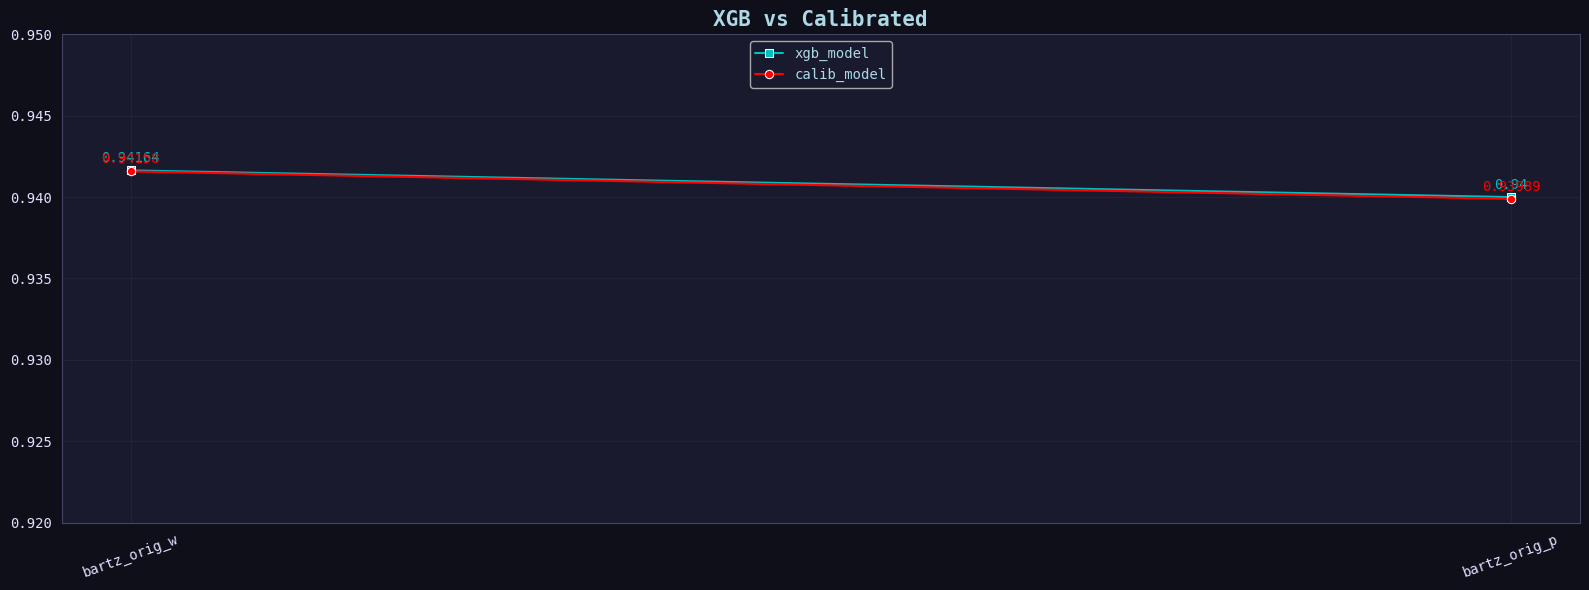

In [47]:
all_model_scores = {}

for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'scores':
            all_model_scores[k] = y

raw_scores, calib_scores, names = [], [], []

for k, group in all_model_scores.items():
    raw_scores.append(group[0])
    calib_scores.append(group[1])
    names.append(k)

plt.figure(figsize=(16, 6))
ax1 = sns.lineplot(raw_scores, marker='s', label='xgb_model')
ax2 = sns.lineplot(calib_scores, marker='o', label='calib_model')

y_add = 5e-4

for i, s1 in enumerate(raw_scores):
    ax1.text(float(i), s1+y_add, s1, ha='center', va='baseline', color='c')

for i, s2 in enumerate(calib_scores):
    ax2.text(float(i), s2+y_add, s2, ha='center', va='baseline', color='r')

plt.ylim((0.92, 0.95))
plt.legend(loc='upper center')
plt.xticks(range(len(names)), names, rotation=20)
plt.title('XGB vs Calibrated', fontdict={'weight': 'semibold', 'size': 15})

plt.tight_layout()
plt.show()

In [48]:
all_model_scores

{'bartz_orig_w': [np.float64(0.94164), np.float64(0.94158)],
 'bartz_orig_p': [np.float64(0.94), np.float64(0.93989)]}

OOF file for base model saved!
OOF file for calibrated model saved!


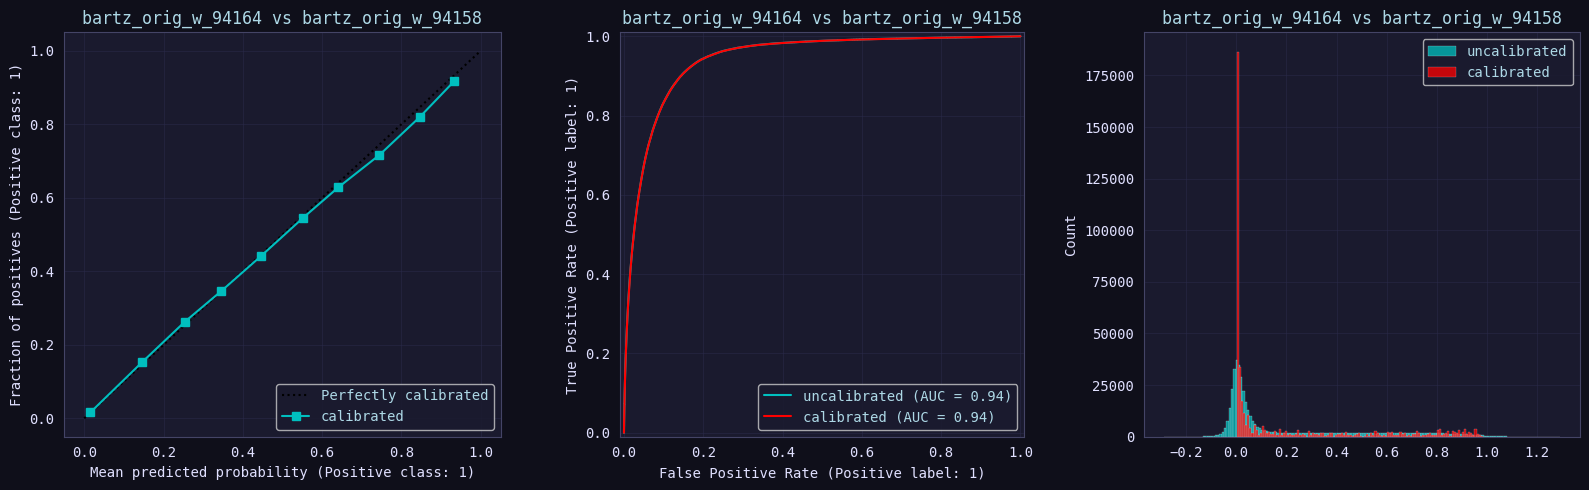


OOF file for base model saved!
OOF file for calibrated model saved!


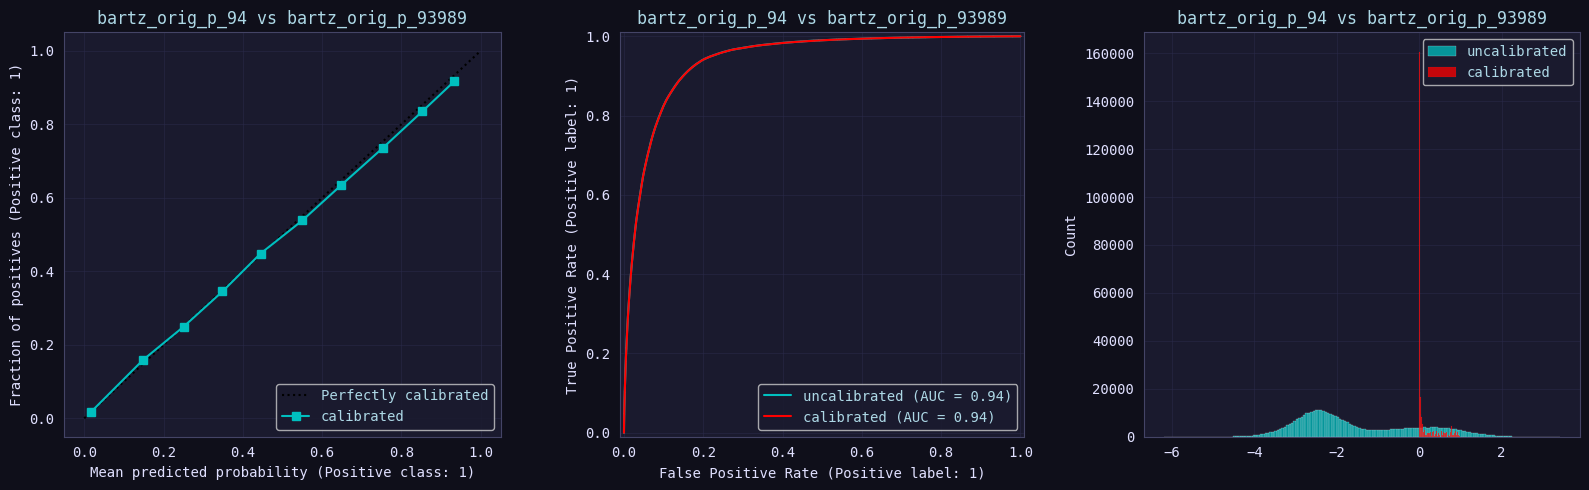

In [49]:
## -- Get oof predictions --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for x, y in v.items():
        if x == 'oof_preds':
            ## -- Create base submission file --
            base_n = f"{k}_{str(raw_scores[i]).split('.')[1]}"
            np.save(f"oof_base_{base_n}.npy", y[0])
            print(f'OOF file for base model saved!')

            ## -- Create calib submission file --
            cal_n = f"{k}_{str(calib_scores[i]).split('.')[1]}"
            np.save(f"oof_{cal_n}.npy", y[1])
            print(f'OOF file for calibrated model saved!')

            ## -- Plot oof distributions --
            _, axs = plt.subplots(1, 3, figsize=(16, 5))
            # CalibrationDisplay.from_predictions(train_data[TARGET], y[0], n_bins=10, name=n, ax=axs[0])
            CalibrationDisplay.from_predictions(train_data[TARGET], y[1], n_bins=10, name='calibrated', ax=axs[0])
            axs[0].set_title(f"{base_n} vs {cal_n}")

            RocCurveDisplay.from_predictions(train_data[TARGET], y[0], name='uncalibrated', ax=axs[1])
            RocCurveDisplay.from_predictions(train_data[TARGET], y[1], name='calibrated', ax=axs[1])
            axs[1].set_title(f"{base_n} vs {cal_n}")

            sns.histplot(y[0], ax=axs[2], label='uncalibrated')
            sns.histplot(y[1], ax=axs[2], label='calibrated')
            axs[2].set_title(f"{base_n} vs {cal_n}")

            plt.legend()
            plt.tight_layout()
            plt.show()

            print()

In [50]:
## -- Get final predictions / submissions --
for i, (k, v) in enumerate(all_model_predictions.items()):
    for j, (x, y) in enumerate(v.items()):
        if x == 'test_preds':
            ## -- Base submission file --
            base_n_1 = f"{k}_{str(raw_scores[i]).split('.')[1]}"
            np.save(f"test_base_{base_n_1}.npy", y[0])
            submit[TARGET] = y[0]
            submit.to_csv(f'submit_base_{base_n_1}.csv', index=False)
            print(f'Submission base predictions saved! {y[0].shape}')

            ## -- Calib submission file --
            cal_n_1 = f"{k}_{str(calib_scores[i]).split('.')[1]}"
            np.save(f"test_{cal_n_1}.npy", y[1])
            submit[TARGET] = y[1]
            submit.to_csv(f'submit_calib_{cal_n_1}.csv', index=False)
            print(f'Submission calib predictions saved! {y[1].shape}')

            print()

submit.head(10)

Submission base predictions saved! (188165,)
Submission calib predictions saved! (188165,)

Submission base predictions saved! (188165,)
Submission calib predictions saved! (188165,)



,id,PitNextLap
0,439140,0.009864
1,439141,0.012373
2,439142,0.011621
3,439143,0.209627
4,439144,0.826675
5,439145,0.277972
6,439146,0.005989
7,439147,0.003733
8,439148,0.061330
9,439149,0.005048
